# Integration of scRNA-seq

During the analysis of scRNA-seq data, we normally have several samples.The main challenge that arises when dealing with multiple samples are the **batch effects**. Batch effects are changes in measured expression levels which can arise due to different reasons. Removing these effects is crucial to allow the joint analysis focussing on finding common structure in the data. In order to remove these batch effects, there are different type of methods, each one solving the issue using specific approaches.

In the DoTools, we included common integration methods used in sc/snRNA-seq data analysis, including: **CCA** (Seurat) and **Harmony** which perform well for simple batch correction tasks and **scVI**, **scANVI** and **Scanorama**, which perform well in more complex data integration tasks.


In [1]:
!wget "https://ndownloader.figshare.com/files/52854605" -O /Users/david/Downloads/adata.h5ad

/Users/david/Downlo 100%[===================>]   3.28G  12.0MB/s    in 3m 49s  

2026-01-20 12:47:30 (14.6 MB/s) - ‘/Users/david/Downloads/adata.h5ad’ saved [3516946145/3516946145]



In [1]:
# Set Up
import dotools_py as do
import scanpy as sc
import session_info

adata = do.io.read_h5ad("/Users/david/Downloads/adata.h5ad")  # Contains two different datasets
adata.X = adata.layers["logcounts"].copy()
adata

AnnData object with n_obs × n_vars = 64845 × 25425
    obs: 'sample', 'condition', 'Experiment', 'leiden1_5', 'autoAnnot', 'annotation', 'leiden5', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'batch', 'age'
    var: 'GeneSymbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'age_colors', 'annotation_colors', 'autoAnnot_colors', 'batch_colors', 'condition_colors', 'hvg', 'leiden1_5', 'leiden1_5_colors', 'leiden5', 'leiden5_colors', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'logcounts'
    obsp: 'connectivities', 'distances'

To perform data integration, we first compute the highly variable genes. This allows both to improve the biological signal recovery and computational performance. This is important, because most of the genes in scRNA-seq are lowly expressed, uninformative across cells or dominated by technical noise.

In [2]:
sc.pp.highly_variable_genes(adata, batch_key='batch') # Detect HVGs shared across samples
adata.var["highly_variable"].value_counts()

highly_variable
False    21748
True      3677
Name: count, dtype: int64

As we can observe, we will use 3,677 highly variable genes instead of the 22,536 genes that we have in our object.
After the selection of HVGs we can proceed with the integration.

## Unintegrated

We first will compute the UMAP embeddings without performing integration using PCA.

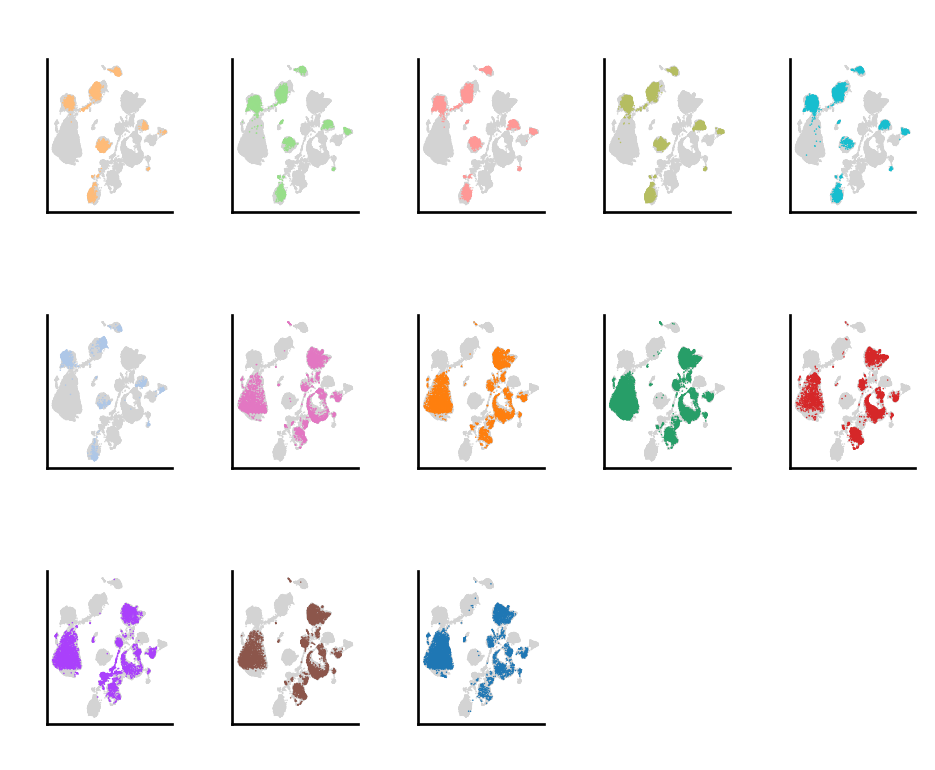

In [3]:
adata_unintegrated = adata.copy()
sc.pp.pca(adata_unintegrated)
do.tl.integrate_data(adata_unintegrated, batch_key="batch", hvg_batch=True, integration_method="pca")
do.pl.split_embeddding(adata_unintegrated, "batch", ncols=5)



## Harmony
In this method, after performing the selection of HVGs, we perform dimensionality reduction, like Principal Component Analysis (PCA). Harmony performs integration by adjusting cell embeddings (typically PCA components) so that cells from different batches align while preserving underlying biological structure. The quality of these embeddings depends heavily on which genes are used to generate them.

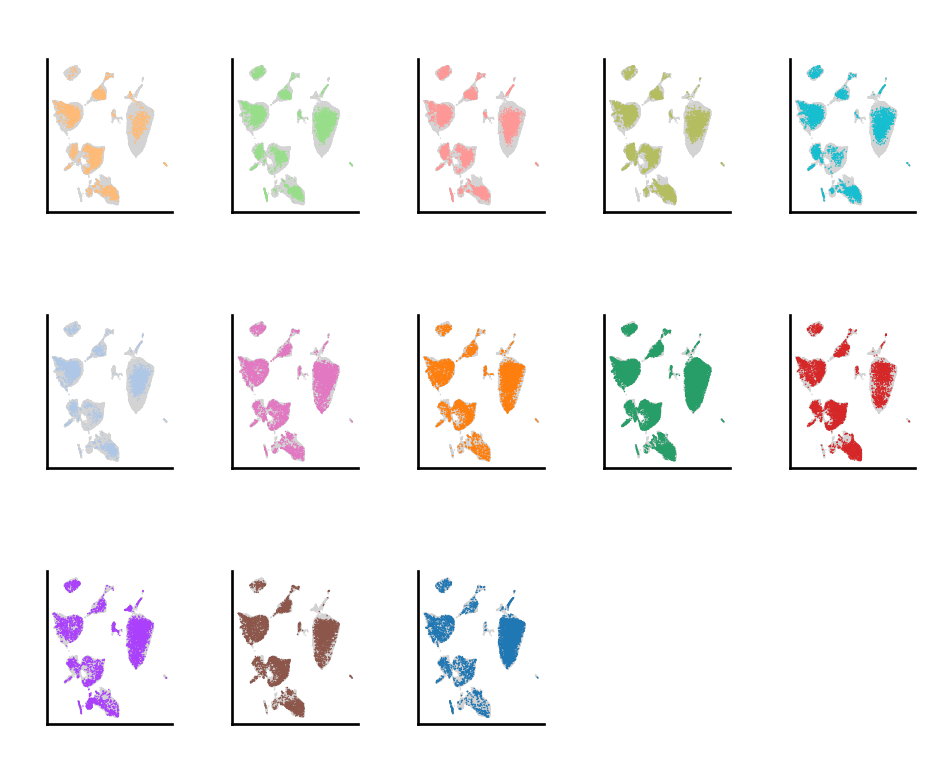

In [7]:
adata_harmony = adata.copy()
do.tl.integrate_data(adata_harmony, batch_key="batch", hvg_batch=True, integration_method="harmony")
do.pl.split_embeddding(adata_harmony, "batch", ncols=5)

In [8]:
adata_harmony.obsm.keys()

KeysView(AxisArrays with keys: X_scVI, X_umap, X_harmony)

After performing integration with Harmony, we have a new representation in `adata.obsm` called **X_harmony**, which contains the batch corrected representation of the data. To perform re-clustering, there are two different approaches: use this representation to find the closest cell neighbors, or re-compute the batch corrected embedding after selecting the cell type or cluster of interest.

## Scanorama
In this method, integration of single-cell datasets is performed by matching biologically similar cells across batches and then computing a non-linear correction that aligns the datasets into a shared low-dimensional space. The core idea is panoramic stitching: identify overlaps between datasets and merge them pairwise, propagating the alignment globally.

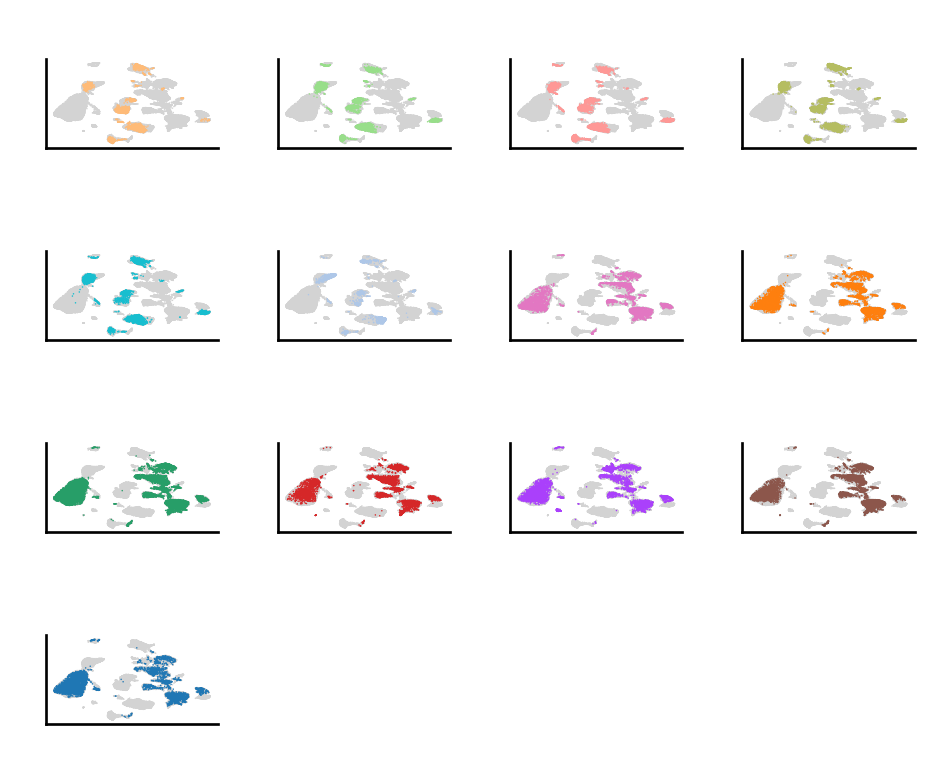

In [9]:
adata_scanorama = adata.copy()
do.tl.integrate_data(adata_scanorama, batch_key="batch", hvg_batch=True, integration_method="scanorama")
do.pl.split_embeddding(adata_scanorama, "batch",  ncols=5)

In [10]:
adata_scanorama.obsm.keys()

KeysView(AxisArrays with keys: X_scVI, X_umap, X_scanorama)

After performing integration with Scanorama, we have a new representation in `adata.obsm` called **X_scanorama**, which contains the batch corrected representation of the data. To perform re-clustering, there are two different approaches: use this representation to find the closest cell neighbors, or re-compute the batch corrected embedding after selecting the cell type or cluster of interest. In our case, we use the second approach in `dotools_py.tl.reclustering`.

## Seurat CCA
The canonical correlation analysis (CCA) is designed to correct batch effects and align shared biological structure across multiple single-cell datasets while preserving meaningful biological variation. CCA is applied to pairs of datasets to find linear combinations of genes (canonical vectors) that are maximally correlated between datasets. These canonical components represent shared sources of biological variation across batches. Using the CCA space, Seurat identifies anchors—pairs of cells from different datasets that are mutual nearest neighbors in the shared low-dimensional space. Anchors serve as correspondences between datasets and encode how datasets should be aligned. Anchors are  then filtered to remove weak or ambiguous matches and are weighted based on similarity. This improves robustness and prevents overcorrection.

Between Seurat v4 and v5 there was a change on how it is performed. In version 4, dimensionality reduction was performed after generated a CCA embedding but in version 5, dimensionality reduction is performed before. This help reducing the computation time, we will use v5 to speed up the analysis.

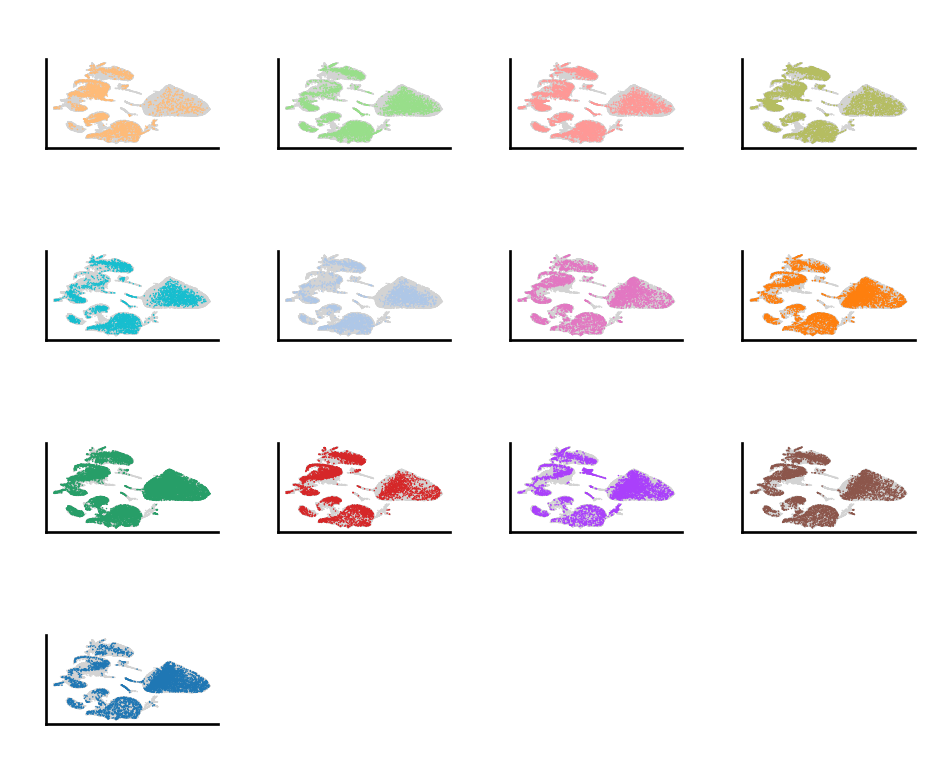

In [17]:
adata_cca5 = adata.copy()
do.tl.integrate_data(adata_cca5, batch_key="batch", hvg_batch=True, integration_method="cca5")
do.pl.split_embeddding(adata_cca5, "batch")

# scVI

The method scVI (single-cell Variational Inference) is a deep generative modeling framework for single-cell RNA-seq data that performs batch correction and integration by learning a shared latent representation of cells. It models gene expression counts using a hierarchical variational autoencoder, typically assuming a negative binomial (or zero-inflated negative binomial) likelihood, while explicitly conditioning on batch and other covariates. During training, scVI separates biological variation from technical effects by encoding cells into a low-dimensional latent space that is invariant to batch, while batch information is modeled in the decoder. The learned latent space can be used for visualization, clustering, and trajectory analysis, and the model enables downstream tasks such as differential expression through probabilistic inference on the original count scale. scVI is particularly effective for large, complex datasets with strong batch effects and does not require explicit feature selection, making it a flexible and scalable integration method.

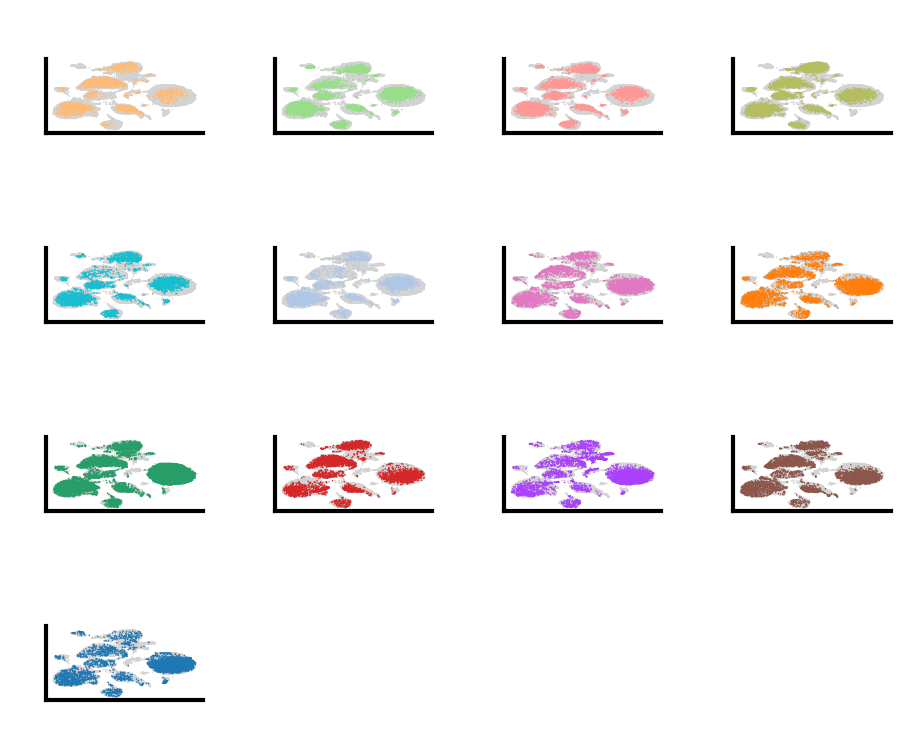

In [6]:
adata_scvi = adata.copy()
do.tl.integrate_data(adata_scvi, batch_key="batch", hvg_batch=True, integration_method="scvi", categorical_covariates=["Experiment"], continuous_covariates=["total_counts"])
do.pl.split_embeddding(adata_scvi, "batch")

## Integration Comparison

We can now also compare how well the integration methods work for this dataset using the ``dotools_py.bm``, we will compute different metrics. The values are scaled between 0 and 1 with larger values indicating a better conservation of biological information.

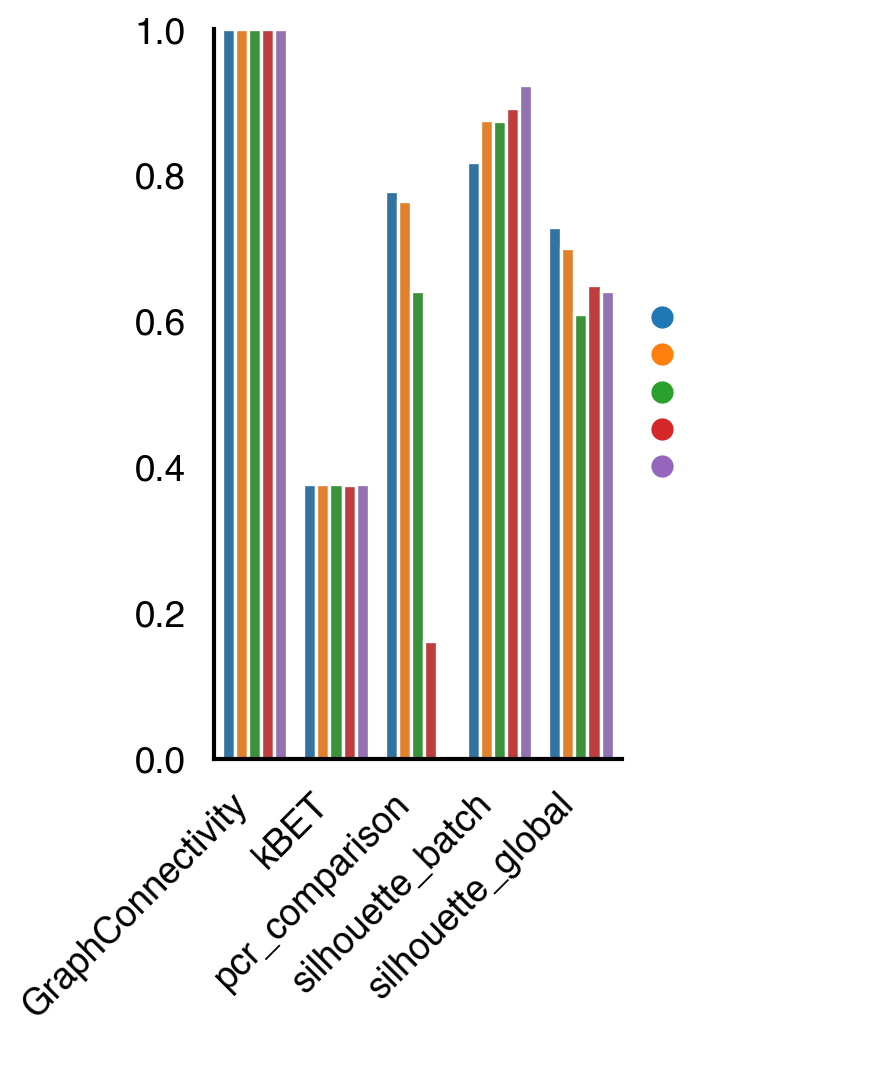

In [5]:
adata_combined = adata.copy()
adata_combined.obsm["X_CCA"] = adata_cca5.obsm["X_CCA"]
adata_combined.obsm["X_harmony"] = adata_harmony.obsm["X_harmony"]
adata_combined.obsm["X_scVI"] = adata_scvi.obsm["X_scVI"]
adata_combined.obsm["X_scanorama"] = adata_scanorama.obsm["X_scanorama"]
adata_combined.obsm["X_pca"] = adata_unintegrated.obsm["X_pca"]


do.bm.eval_integration(
    adata_post=adata_combined,
    adata_pre=adata_unintegrated,
    batch_key="batch",
    annotation_key="annotation",
    use_rep=["X_CCA", "X_harmony", "X_scVI", "X_scanorama", "X_pca"]
)

In [19]:
adata_combined.write("/Users/david/Downloads/adata_combined.h5ad")

In [9]:
session_info.show(na=False, cpu=True, excludes=["backports"], std_lib=True, dependencies=True, html=True)

In [11]:
import platform
import psutil

print("OS:", platform.platform())
print("Machine:", platform.machine())
print("Processor:", platform.processor())
print("CPU cores (physical):", psutil.cpu_count(logical=False))
print("CPU cores (logical):", psutil.cpu_count(logical=True))
print("Total RAM (GB):", round(psutil.virtual_memory().total / (1024 ** 3), 2))
print("Python version:", platform.python_version())


OS: macOS-26.2-arm64-arm-64bit
Machine: arm64
Processor: arm
CPU cores (physical): 10
CPU cores (logical): 10
Total RAM (GB): 16.0
Python version: 3.11.13
